# Decision Tree Regressor - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. Why a regression tree is a **staircase function**: it chops feature space into
   rectangles and predicts one flat number per rectangle.
2. How a tree **scores a candidate split** using squared-error reduction:
   $$\Delta = SSE_{parent} - \frac{n_L}{n}\,SSE_L - \frac{n_R}{n}\,SSE_R$$
3. How to evaluate a real split (`total_bill <= 15`) **by hand** on restaurant tips.
4. That sklearn's depth-1 tree predicts exactly the **group means** - we prove it line by line.
5. What growing depth does: 2 steps → 8-ish steps → **pure memorization**.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # turn on inline plotting when this file executes inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # identical to the %matplotlib inline magic
except NameError:  # running as a plain .py script has no IPython shell - skip quietly
    pass

import numpy as np                  # vectorised maths + random numbers
import pandas as pd                 # DataFrames for loading/wrangling tables
import matplotlib.pyplot as plt     # figure/axes control underneath seaborn
import seaborn as sns               # attractive statistical plots with little code
from sklearn.tree import DecisionTreeRegressor, export_text  # the tree + its text rule-book

np.random.seed(42)                  # freeze numpy's RNG so any randomness is repeatable
sns.set_theme()                     # apply seaborn's clean default look to all plots
plt.rcParams["figure.dpi"] = 100    # render figures at 100 dpi (crisp but light)


### 1. The data: can bill size predict the tip?

We use the classic `tips` table (244 restaurant visits). It is small,
has one strong driver (`total_bill`), and is perfect for watching the tree
machinery work **one split at a time**. 💡 Keep only two columns here -
this lesson is about mechanics, not feature engineering.

In [2]:
from pathlib import Path  # object-oriented filesystem paths (cleaner than raw strings)

def find_data_dir():
    # Walk upward from wherever this notebook runs until we reach the course's
    # '02_machine_learning' folder, then point at its shared 'data' sub-folder.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # step one directory up and test again
    return here / "data"

DATA_DIR = find_data_dir()  # resolved once; every notebook in the course lands here

def load_tips():
    # Download-once helper: reuse the local CSV if present, otherwise fetch it.
    csv_path = DATA_DIR / "tips.csv"
    if not csv_path.exists():       # true only on the very first run (or after cache deletion)
        import urllib.request       # stdlib downloader - no extra dependencies needed
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")  # tell the learner the cache got filled
    return pd.read_csv(csv_path)    # afterwards always read straight from disk

tips = load_tips()[["total_bill", "tip"]]  # keep only the two columns this lesson needs
print(tips.shape)   # (rows, columns) - expect (244, 2)
tips.head()         # eyeball five example visits before doing any maths

(244, 2)


,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


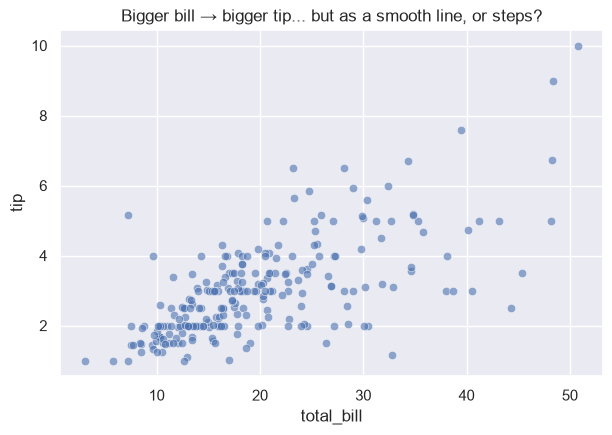

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))     # one modest canvas for the raw data
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax, alpha=0.6)  # dot = one table
ax.set_title("Bigger bill → bigger tip... but as a smooth line, or steps?")
plt.show()           # render now so the narrative order stays clean

### 2. The root node: worst possible model, measured precisely

Before asking ANY question, the tree measures how bad it currently is.
With squared error, the best constant guess for a node is its **mean** $\bar y$,
and the total error is:

$$SSE_{root} = \sum_{i=1}^{n}(y_i - \bar y)^2$$

This number is the baseline every future split will try to shrink.
💡 Useful identity: $SSE = n \cdot Var(y)$ - so "SSE reduction" IS "variance reduction".

In [4]:
y = tips["tip"].to_numpy()             # target as a plain numpy array (fast vector maths)
n = len(y)                             # number of observations sitting in the root
y_bar = y.mean()                       # mean tip = THE optimal constant prediction for SSE
sse_root = ((y - y_bar) ** 2).sum()    # sum of squared distances from every point to that mean

print(f"rows in root node      : {n}")
print(f"mean tip (best constant): ${y_bar:.4f}")   # what a 'predict-the-mean' dummy model says
print(f"SSE of the root node   : {sse_root:.2f}")  # the score to beat with our first question
print(f"identity check SSE == n*Var: {np.isclose(sse_root, n * y.var(ddof=0))}")  # algebra sanity

rows in root node      : 244
mean tip (best constant): $2.9983
SSE of the root node   : 465.21
identity check SSE == n*Var: True


### 3. Scoring ONE candidate split by hand

Candidate question: **"is total_bill <= \$15?"** It routes every visit into a
low-bill group ($L$) or high-bill group ($R$). Each child then predicts its own
mean, so each child gets its own SSE. The split's worth is how much squared
error it removes, weighting children by their share of rows:

$$\Delta = SSE_{parent} - \Big(\tfrac{n_L}{n}SSE_L + \tfrac{n_R}{n}SSE_R\Big)$$

⚠️ The weighting matters: improving a huge group counts much more than
polishing a tiny one - otherwise trees would chase little cliques of points.

### Candidate cut-point chosen by eye, scored EXACTLY like CART scores it:


In [ ]:
thr = 15.0                                          # our guess: "cheap bills vs pricey bills"
bill = tips["total_bill"].to_numpy()                # feature column as numpy for masking
left = y[bill <= thr]                               # rows answering YES go left
right = y[bill > thr]                              # rows answering NO go right

sse_left = ((left - left.mean()) ** 2).sum()        # left child predicts ITS OWN mean
sse_right = ((right - right.mean()) ** 2).sum()     # right child likewise

nL, nR = len(left), len(right)
weighted_children = (nL / n) * sse_left + (nR / n) * sse_right   # size-weighted cost
delta_15 = sse_root - weighted_children             # variance removed by this question

print(f"left  child: n={nL:3d}  mean={left.mean():5.2f}  SSE={sse_left:8.2f}")
print(f"right child: n={nR:3d}  mean={right.mean():5.2f}  SSE={sse_right:8.2f}")
print(f"weighted child SSE : {weighted_children:.2f}")
print(f"SSE drop  Delta = {sse_root:.2f} - {weighted_children:.2f} = {delta_15:.2f}"
      f"   ({delta_15 / sse_root:.1%} of parent error removed)")


### 4. sklearn's depth-1 tree - and proof it predicts group means

Our `$15` guess was reasonable, but CART doesn't guess: it scans **every**
possible threshold of every feature and keeps the maximiser of $\Delta$.
A depth-1 tree therefore has exactly one question and two leaves - and each
leaf MUST output the mean of the training tips routed there. Let's verify both
claims empirically rather than take them on faith.

In [6]:
from sklearn.tree import DecisionTreeRegressor, export_text

X = tips[["total_bill"]]          # sklearn wants a 2-D feature matrix
tree1 = DecisionTreeRegressor(max_depth=1, random_state=42).fit(X, y)

print(export_text(tree1, feature_names=["total_bill"]))

thr_best = float(tree1.tree_.threshold[0])          # the cut-point CART picked
pred_sk = tree1.predict(X)
mean_L = y[X["total_bill"].to_numpy() <= thr_best].mean()
mean_R = y[X["total_bill"].to_numpy() > thr_best].mean()

# rebuild predictions by hand -> PROVES leaves store group means:
manual = np.where(X["total_bill"].to_numpy() <= thr_best, mean_L, mean_R)
print("sklearn predictions == group means :",
      np.allclose(pred_sk, manual))

_maskL = X["total_bill"].to_numpy() <= thr_best
_maskR = ~_maskL
# SIZE-WEIGHTED child cost (same formula as cell 8!) - forgetting the
# weights here would silently favor lopsided splits:
sse_children = ((len(y[_maskL]) / len(y)) *
                ((y[_maskL] - mean_L) ** 2).sum()
                + (len(y[_maskR]) / len(y)) *
                ((y[_maskR] - mean_R) ** 2).sum())
delta_best = sse_root - sse_children

print(f"Delta at our $15 guess        : {delta_15:8.2f}")
print(f"Delta at CART's optimal cut   : {delta_best:8.2f}")
assert delta_best >= delta_15       # optimality: the searched cut must win

|--- total_bill <= 20.47
|   |--- value: [2.40]
|--- total_bill >  20.47
|   |--- value: [4.00]

sklearn predictions == group means : True
Delta at our $15 guess        :   238.73
Delta at CART's optimal cut   :   320.08


### 5. Depth ladder: 2 steps → 8 steps → memorization

Depth controls **how many rectangles** the staircase has (a balanced binary
tree of depth $d$ can have up to $2^d$ leaves). Watch the prediction function
evolve as we relax the limit:

- `depth=1`: one threshold, two flat levels - badly **underfits** curvature.
- `depth=3`: up to 8 levels - starts tracing the cloud's shape.
- unpruned: grows until every leaf is tiny - the curve threads almost every point.

⚠️ That last one looks impressive but is pure memorization: check the
training residuals below and compare with honest out-of-sample behaviour in
the workflow notebook.

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


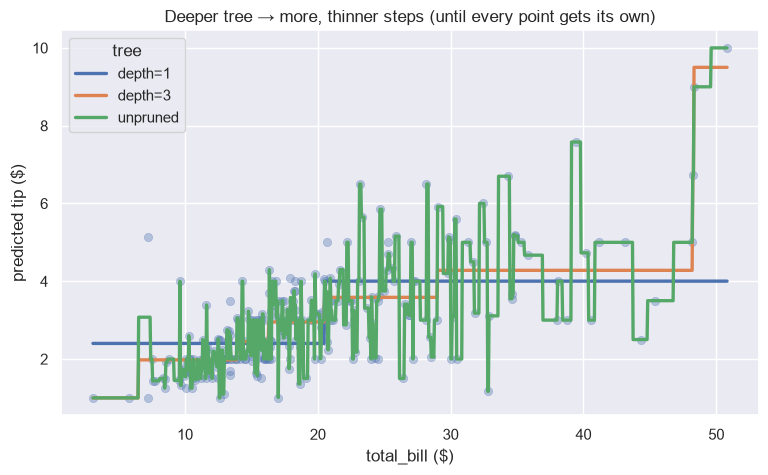

In [7]:
models = {
    "depth=1": DecisionTreeRegressor(max_depth=1, random_state=42),
    "depth=3": DecisionTreeRegressor(max_depth=3, random_state=42),
    "unpruned": DecisionTreeRegressor(random_state=42),  # no limits: splits until leaves are tiny
}

xs = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 1000)[:, None]
# ^ dense grid of bills to query; [:, None] reshapes to the (n_samples, 1) matrix sklearn wants

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax, alpha=0.35, edgecolor=None)  # backdrop data
for name, mdl in models.items():              # fit each depth variant and draw its step function
    mdl.fit(X, y)                             # same data, different stopping rule
    ax.plot(xs, mdl.predict(xs), lw=2.4, label=name)  # dense grid makes the stairs visible
ax.legend(title="tree")
ax.set_title("Deeper tree → more, thinner steps (until every point gets its own)")
ax.set_xlabel("total_bill ($)"); ax.set_ylabel("predicted tip ($)")
plt.show()

In [8]:
for name, mdl in [("depth=1", models["depth=1"]),
                  ("depth=3", models["depth=3"]),
                  ("unpruned", models["unpruned"])]:
    resid = y - mdl.predict(X)                # IN-SAMPLE errors - the flattering kind
    print(f"{name:>9}: leaves={mdl.get_n_leaves():3d}  "
          f"train R2={mdl.score(X, y):6.3f}  max|train residual|={np.abs(resid).max():.3f}$")

  depth=1: leaves=  2  train R2= 0.314  max|train residual|=5.998$
  depth=3: leaves=  8  train R2= 0.556  max|train residual|=3.299$
 unpruned: leaves=221  train R2= 0.963  max|train residual|=2.075$


### Summary & key takeaways

- A regression tree is a **staircase**: nested yes/no questions carve the
  feature axis into regions; each region predicts its training **mean**.
- Split quality = variance removal,
  $\Delta = SSE_{parent} - (\tfrac{n_L}{n}SSE_L + \tfrac{n_R}{n}SSE_R)$;
  CART picks the threshold maximising it (our hand-computed $15 could never beat it).
- Depth-1 predictions are *exactly* group means - verified numerically above.
- Unpruned depth ⇒ near-zero **training** error = memorization, not learning;
  pruning (`max_depth`, `min_samples_leaf`, `ccp_alpha`) is non-negotiable.

💡 Next: `02_model_development_workflow.nb.py` tests these ideas honestly with
train/test splits and cross-validation on the California housing dataset.